In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lasio

# Perfilagem geofísica de poços

A atividade de perfilagem geofísica de poços consiste em realizar uma série de medidas relacionadas às propriedades físicas das rochas — tais como raios gama, resistividade, velocidade sônica, densidade e porosidade — ao longo de um poço perfurado (ou em perfuração).

Os principais objetivos da perfilagem são:

* **Avaliação de formações**: determinar a litologia e estimar propriedades indiretas, tais como porosidade, permeabilidade, saturação de fluidos (água, óleo e gás) e pressão;
* **Cálculo de net pay**: identificar zonas com potencial para acúmulo de hidrocarbonetos;
* **Amarração sísmica-poço**: realizar a integração entre os dados sísmicos e de poços (velocidade sônica e densidade);
* **Caracterização e monitoramento de reservatórios**: compreender a geometria e a distribuição das propriedades ao longo do reservatório, bem como avaliar a variação dessas propriedades durante a produção de hidrocarbonetos.


![Seção esquemática de uma perfilagem](https://www.researchgate.net/publication/367157378/figure/fig5/AS:11431281113205429@1673772449160/Wireline-logging-tools-a-depicts-elements-of-logging-tool-viz-measurement-sonde.png "Perfilagem geofísica de poços")

## Tipos de arquivo

Os perfis geofísicos podem ser apresentados em dois principais tipos de arquivos: **.LAS** (*Log ASCII Standard*) e **.DLIS** (*Digital Log Interchange Standard*).

---

### **.LAS** (*Log ASCII Standard*)

O formato **.LAS** é um arquivo de texto (ASCII) amplamente utilizado na indústria de óleo e gás. Ele é também o principal tipo de arquivo para carregamento em softwares de interpretação sísmica e de poços.

Sua estrutura é composta por:

* **Cabeçalho** — contém informações sobre o poço, perfis (logs) presentes, unidades de medida, propriedades da lama, entre outros metadados;
* **Perfis (logs)** — registros quantitativos e qualitativos das propriedades físicas medidas ao longo do poço.

---

### **.DLIS** (*Digital Log Interchange Standard* — *Logging Industry Data Standard, LIDS*)

O formato **.DLIS** é um tipo de arquivo binário que armazena os registros de poço em diferentes blocos lógicos, referenciados internamente por identificadores. É um formato mais complexo que o `.LAS`, capaz de armazenar não apenas medições petrofísicas, mas também uma ampla gama de informações associadas ao poço, tais como:

* **Cabeçalhos das medições**;
* **Testes de formação**;
* **Dados de pressão e temperatura**;
* **Análises laboratoriais de amostras de rochas**; e
* **Registros de testemunhos** — descrição e análise de testemunhos de sondagem.


In [ ]:
# Carregando perfil no formato .las
#!wget https://raw.githubusercontent.com/alexsandrocerqueira/Curso_UnB_IA/main/Dados/Wells/3-_BLV_3_BA/3-BLV-0003-BA.LAS
well = lasio.read("Dados/Wells/3-_BLV_3_BA/3-BLV-0003-BA.LAS")
well

In [3]:
#Verificando os parâmetros do poço
well.header.keys()

dict_keys(['Version', 'Well', 'Curves', 'Parameter', 'Other'])

In [4]:
#Informações do poço
well.well

[HeaderItem(mnemonic="STRT", unit="M", value="240.03", descr="Start Depth"),
 HeaderItem(mnemonic="STOP", unit="M", value="1741.932", descr="Stop  Depth"),
 HeaderItem(mnemonic="STEP", unit="M", value="0.1524", descr="Step"),
 HeaderItem(mnemonic="NULL", unit="", value="-99999.0", descr="Null Value"),
 HeaderItem(mnemonic="COMP", unit="", value="PETROLEO BRASILEIRO S/A", descr="C"),
 HeaderItem(mnemonic="WELL", unit="", value="3BLV 0003  BA", descr="Well"),
 HeaderItem(mnemonic="FLD", unit="", value="BELA VISTA", descr="Field"),
 HeaderItem(mnemonic="LOC", unit="", value="", descr="Location"),
 HeaderItem(mnemonic="STAT", unit="", value="BAHIA", descr="State"),
 HeaderItem(mnemonic="SRVC", unit="", value="", descr="Service Company"),
 HeaderItem(mnemonic="DATE", unit="", value="", descr="Log Date"),
 HeaderItem(mnemonic="API", unit="", value="202400428600", descr="API Code")]

In [5]:
# Mostrando os metadados do perfil
for i in well.well:
    print(f"{i.mnemonic :>10} | {i.value :>20} | {i.unit :>10} | {i.descr :>15}")

      STRT |               240.03 |          M |     Start Depth
      STOP |             1741.932 |          M |     Stop  Depth
      STEP |               0.1524 |          M |            Step
      NULL |             -99999.0 |            |      Null Value
      COMP | PETROLEO BRASILEIRO S/A |            |         Company
      WELL |        3BLV 0003  BA |            |            Well
       FLD |           BELA VISTA |            |           Field
       LOC |                      |            |        Location
      STAT |                BAHIA |            |           State
      SRVC |                      |            | Service Company
      DATE |                      |            |        Log Date
       API |         202400428600 |            |        API Code


In [6]:
# Mostrando as curvas do perfil
print(f"{'Mneumonico':>10} | {'Unid.':>6} | {'Value':>6} | Descrição")
for i in well.curves:
    print(f"{i.mnemonic:>10} | {i.unit or '-':>6} | {i.value or '-':>6} | {i.descr}")

Mneumonico |  Unid. |  Value | Descrição
      DEPT |      M |      - | Measured Depth
      CALI |      - |     IN | CALIPER
      CILD |      - |   MMHO | CALIBRATED DEEP INDUCTION CONDUCTIVITY
      DRHO |      - |   G/C3 | BULK DENSITIY CORRECTION
        DT |      - |   US/F | DELTA-T (ALSO CALLED SLOWNESS OR INTERVAL TRANSIT TIME)
        GR |      - |   GAPI | GAMMA RAY
       ILD |      - |  OHM.M | INDUCTION DEEP RESISTIVITY
      NPHI |      - |     PU | THERMAL NEUTRON POROSITY (ORIGINAL RATIO METHOD) IN SELECTED LITHOLOGY
       PEF |      - |      - | 
      RHOB |      - |   G/CC | BULK DENSITY
      SFLA |      - |  OHM.M | SFL RESISTIVITY AVERAGE OVER 2.5 FEET
      SFLU |      - |  OHM.M | SFL RESISTIVITY UNAVERAGED


In [7]:
# Acessando informações disponíveis no atributo curves
well.curves

[CurveItem(mnemonic="DEPT", unit="M", value="", descr="Measured Depth", original_mnemonic="DEPT", data.shape=(9855,)),
 CurveItem(mnemonic="CALI", unit="", value="IN", descr="CALIPER", original_mnemonic="CALI", data.shape=(9855,)),
 CurveItem(mnemonic="CILD", unit="", value="MMHO", descr="CALIBRATED DEEP INDUCTION CONDUCTIVITY", original_mnemonic="CILD", data.shape=(9855,)),
 CurveItem(mnemonic="DRHO", unit="", value="G/C3", descr="BULK DENSITIY CORRECTION", original_mnemonic="DRHO", data.shape=(9855,)),
 CurveItem(mnemonic="DT", unit="", value="US/F", descr="DELTA-T (ALSO CALLED SLOWNESS OR INTERVAL TRANSIT TIME)", original_mnemonic="DT", data.shape=(9855,)),
 CurveItem(mnemonic="GR", unit="", value="GAPI", descr="GAMMA RAY", original_mnemonic="GR", data.shape=(9855,)),
 CurveItem(mnemonic="ILD", unit="", value="OHM.M", descr="INDUCTION DEEP RESISTIVITY", original_mnemonic="ILD", data.shape=(9855,)),
 CurveItem(mnemonic="NPHI", unit="", value="PU", descr="THERMAL NEUTRON POROSITY (ORI

In [8]:
well.params

[]

In [9]:
well.other

''

### Convertendo de lasio para dataframe

In [10]:
df = well.df() #.df() converte os dados do poço em um DataFrame do pandas
df.head()

,CALI,CILD,DRHO,DT,GR,ILD,NPHI,PEF,RHOB,SFLA,SFLU
DEPT,,,,,,,,,,,
240.030,9.9470,118.0263,NaN,91.0978,81.4306,8.5009,NaN,NaN,NaN,5.9176,5.4546
240.182,9.7775,128.3341,NaN,86.0042,81.0654,7.7926,NaN,NaN,NaN,6.8221,7.1226
240.335,9.7262,129.1740,NaN,82.9595,81.7815,7.7374,NaN,NaN,NaN,8.0991,9.6179
240.487,9.7077,125.9436,NaN,81.3112,79.9990,7.9434,NaN,NaN,NaN,9.4095,12.1485
240.640,9.7038,119.3938,NaN,80.9584,76.8010,8.3889,NaN,NaN,NaN,10.5798,13.8837


In [11]:
#Verificando a presença de valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9855 entries, 240.03 to 1741.78
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CALI    7063 non-null   float64
 1   CILD    9843 non-null   float64
 2   DRHO    2758 non-null   float64
 3   DT      9764 non-null   float64
 4   GR      9784 non-null   float64
 5   ILD     9843 non-null   float64
 6   NPHI    2713 non-null   float64
 7   PEF     2758 non-null   float64
 8   RHOB    2758 non-null   float64
 9   SFLA    9843 non-null   float64
 10  SFLU    9843 non-null   float64
dtypes: float64(11)
memory usage: 923.9 KB


In [12]:
df

,CALI,CILD,DRHO,DT,GR,ILD,NPHI,PEF,RHOB,SFLA,SFLU
DEPT,,,,,,,,,,,
240.030,9.9470,118.0263,NaN,91.0978,81.4306,8.5009,NaN,NaN,NaN,5.9176,5.4546
240.182,9.7775,128.3341,NaN,86.0042,81.0654,7.7926,NaN,NaN,NaN,6.8221,7.1226
240.335,9.7262,129.1740,NaN,82.9595,81.7815,7.7374,NaN,NaN,NaN,8.0991,9.6179
240.487,9.7077,125.9436,NaN,81.3112,79.9990,7.9434,NaN,NaN,NaN,9.4095,12.1485
240.640,9.7038,119.3938,NaN,80.9584,76.8010,8.3889,NaN,NaN,NaN,10.5798,13.8837
...,...,...,...,...,...,...,...,...,...,...,...
1741.170,8.2812,NaN,0.0628,NaN,NaN,NaN,NaN,3.7851,2.4964,NaN,NaN
1741.322,8.2812,NaN,0.0456,NaN,NaN,NaN,NaN,3.7280,2.4780,NaN,NaN
1741.475,8.2812,NaN,0.0329,NaN,NaN,NaN,NaN,3.6619,2.4633,NaN,NaN


In [13]:
#Adicionando manualmente o topo e base das formações

df['Formation'] = np.nan

df['Formation'][(df.index >= 60 )&(df.index <= 242)] = 'Salvador'
df['Formation'][(df.index > 242) & (df.index <= 392)]  = 'Sesmaria'
df['Formation'][(df.index > 392) & (df.index <= 1647)]  = 'Candeias'
df['Formation'][(df.index > 1647) & (df.index <= 1687)]  = 'Agua Grande'
df['Formation'][df.index > 1687] = 'Sergi'

C:\Users\Acer3\AppData\Local\Temp\ipykernel_34976\322560979.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Salvador' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['Formation'][(df.index >= 60 )&(df.index <= 242)] = 'Salvador'


In [14]:
#Pegando o valor minimo e máximo de cada formação
for i in df['Formation'].unique():
    formation_data = df[df['Formation'] == i]
    formation_min = formation_data.index.min()
    formation_max = formation_data.index.max()
    print(f"Formação: {i} | Profundidade Mínima: {formation_min} | Profundidade Máxima: {formation_max}")

formation_min = df['Formation'].min()
formation_max = df['Formation'].max()   

Formação: Salvador | Profundidade Mínima: 240.03 | Profundidade Máxima: 241.859
Formação: Sesmaria | Profundidade Mínima: 242.011 | Profundidade Máxima: 391.973
Formação: Candeias | Profundidade Mínima: 392.125 | Profundidade Máxima: 1646.987
Formação: Agua Grande | Profundidade Mínima: 1647.139 | Profundidade Máxima: 1686.916
Formação: Sergi | Profundidade Mínima: 1687.068 | Profundidade Máxima: 1741.78


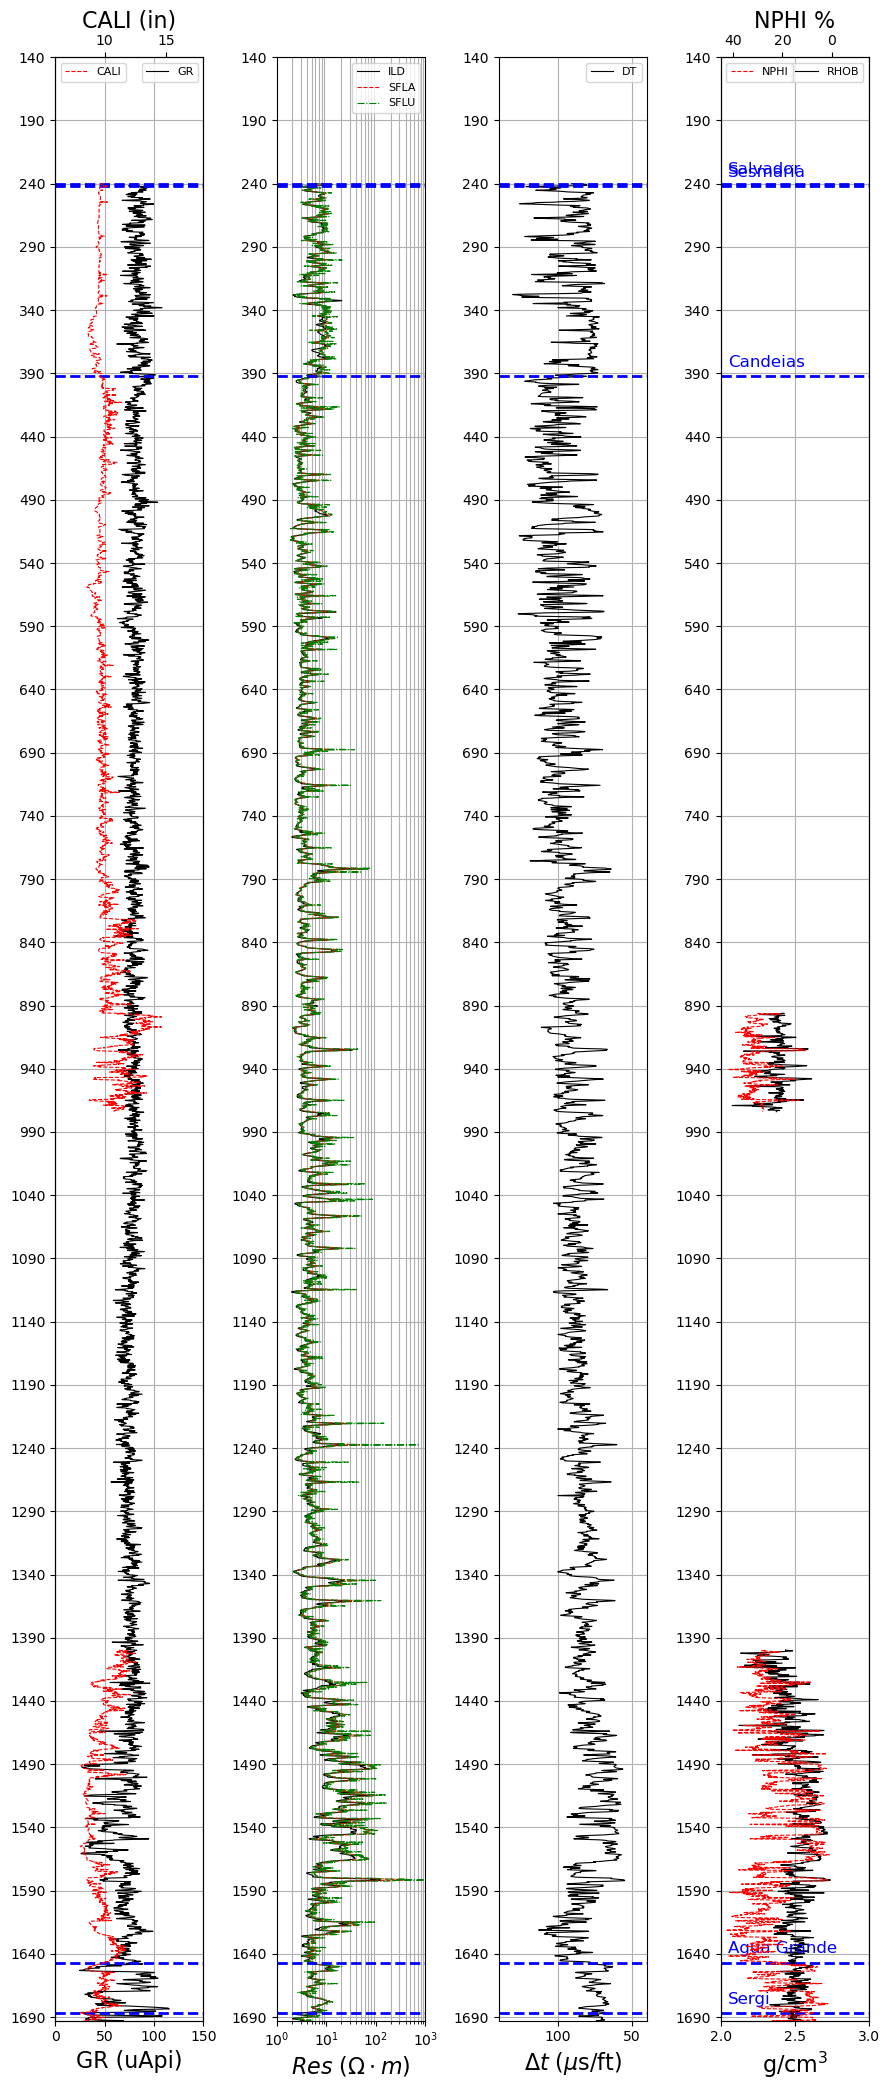

In [15]:
# Plotando as curvas do perfil

fig,axes = plt.subplots(nrows=1, ncols=4, figsize=(9,21))

y_lim = (df.index.min()-100, df.index.max()+1)
step = 50

for ax in axes:
    ax.set_yticks(np.arange(y_lim[0], y_lim[1], step))
    ax.set_ylim(y_lim[0], y_lim[1]-step)
    ax.invert_yaxis()
    ax.grid()
    
axes[0].plot(df.GR,df.index,lw=0.8,color='black',label='GR')
axes[0].set_xlim(0,150)
axes[0].set_xlabel('GR (uApi)',fontsize=16)

#Adicionando um eixo gêmeo para o caliper
axes0 = axes[0].twiny()
axes0.plot(df.CALI,df.index,lw=0.8,color='red',ls='--',label='CALI')
axes0.set_xlabel('CALI (in)',fontsize=16)
axes0.set_xlim(6,18)
axes0.legend(loc='upper left',fontsize=8)
    

axes[1].semilogx(df.ILD,df.index,lw=0.8,color='black',label='ILD')
axes[1].semilogx(df.SFLA,df.index,color='red',lw=0.8,ls='--',label='SFLA')
axes[1].semilogx(df.SFLU,df.index,color='green',lw=0.8,ls='-.',label='SFLU')
axes[1].set_xlabel(r'$Res$ ($\Omega \cdot m$)',fontsize=16)
axes[1].set_xlim(1, 1000)
axes[1].set_xticks([1,10,100,1000])
axes[1].grid(which='both',axis='x')


axes[2].plot(df.DT,df.index,lw=0.8,color='black',label='DT')
axes[2].set_xlim(140,40)
axes[2].set_xlabel(r'$\Delta t$ ($\mu$s/ft)',fontsize=16)


axes[3].plot(df.RHOB,df.index,lw=0.8,color='black',label='RHOB')
axes[3].set_xlim(2,3)
axes[3].set_xlabel(r'g/cm$^3$',fontsize=16)

axes3 = axes[3].twiny()

axes3.plot(df.NPHI,df.index,lw=0.8,color='red',ls='--',label='NPHI')
axes3.set_xlabel('NPHI %',fontsize=16)
axes3.set_xlim(45,-15)
axes3.legend(loc='upper left',fontsize=8)


# Plotando as formações
for formation in df['Formation'].unique():
    formation_data = df[df['Formation'] == formation]
    formation_min = formation_data.index.min()
    
    for ax in axes:
        ax.legend(fontsize=8)
        ax.axhline(formation_min, color='blue', lw=2, ls='--')
        #Adicionando o nome da Formaçõa imediatamente acima da linha só no último eixo
        if ax == axes[-1]:
            ax.text(ax.get_xlim()[0]+(ax.get_xlim()[1]-ax.get_xlim()[0])*0.05, 
                    formation_min - 5, 
                    formation, 
                    color='blue', 
                    fontsize=12, 
                    verticalalignment='bottom')

fig.tight_layout()

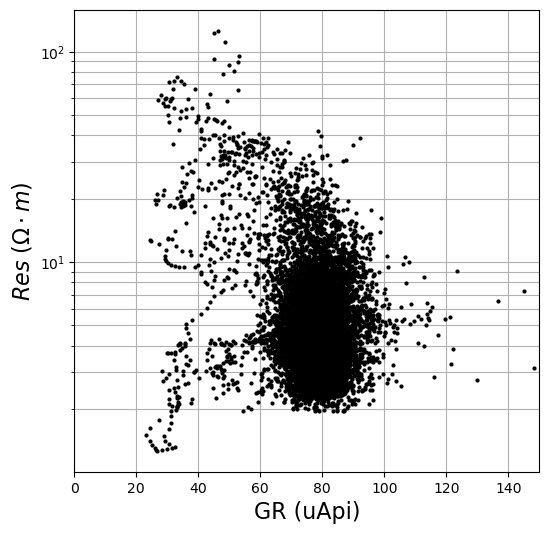

In [16]:
# Plotando crossplot GR x Resistividade

fig,axes = plt.subplots(nrows=1, ncols=1, figsize=(6,6))
axes.semilogy(df.GR, df.ILD, marker='o', linestyle='', color='black', markersize=2)
axes.set_xlabel('GR (uApi)', fontsize=16)
axes.set_ylabel(r'$Res$ ($\Omega \cdot m$)', fontsize=16)
axes.set_xlim(0,150)
axes.grid(which='both')

In [17]:
df[df.Formation == formation]['RHOB']

DEPT
1687.068    2.4719
1687.220    2.4712
1687.373    2.4897
1687.525    2.4917
1687.678    2.4835
             ...  
1741.170    2.4964
1741.322    2.4780
1741.475    2.4633
1741.627    2.4605
1741.780    2.4753
Name: RHOB, Length: 360, dtype: float64

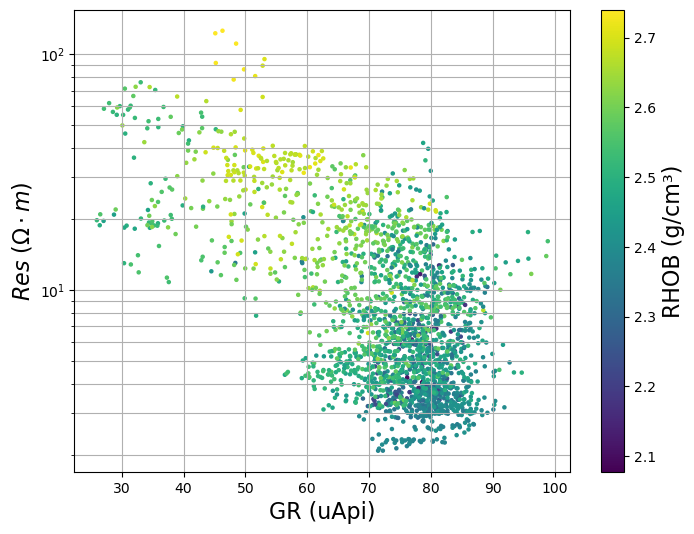

In [18]:
#Adicionando uma terceira variável com cor e filtrando por formação
fig,axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))

formation = 'Candeias'

plot = axes.scatter(df[df.Formation == formation].GR, 
                        df[df.Formation == formation]['ILD'], 
                        c=df[df.Formation == formation]['RHOB'], 
                        cmap='viridis',marker='o',s=5)

axes.set_yscale('log')
axes.grid(which='both')

axes.set_xlabel('GR (uApi)', fontsize=16)
axes.set_ylabel(r'$Res$ ($\Omega \cdot m$)', fontsize=16)

cbar = fig.colorbar(plot, ax=axes)
cbar.set_label('RHOB (g/cm³)', fontsize=16)

In [ ]:
#Funções para cálculo de argilosidade
def igr(gr, gr_min, gr_max):
    """Calcula a argilosidade usando o método de índice de argila (IGR)"""
    return ((gr - gr_min) / (gr_max - gr_min)).clip(0,1)

def vsh_steiber(igr,cte=2):
    """Calcula a volume de argila usando o método de Steiber"""
    return igr / (3 - cte * df['IGR'])

In [20]:
#Calculando a argilosidade do Candeia

df['IGR'] = np.nan

gr_min = 55
gr_max = 90

#Substituindo os valores de argilosidade na coluna IGR apenas para a formação Candeias
df.loc[df['Formation'] == 'Candeias', 'IGR'] = igr(df[df['Formation'] == 'Candeias']['GR'], gr_min, gr_max)

#Calculando a argilosidade por Steiber
df['Vsh_Steiber'] = np.nan

df.loc[df['Formation'] == 'Candeias', 'Vsh_Steiber'] = vsh_steiber(df[df['Formation'] == 'Candeias']['IGR'])

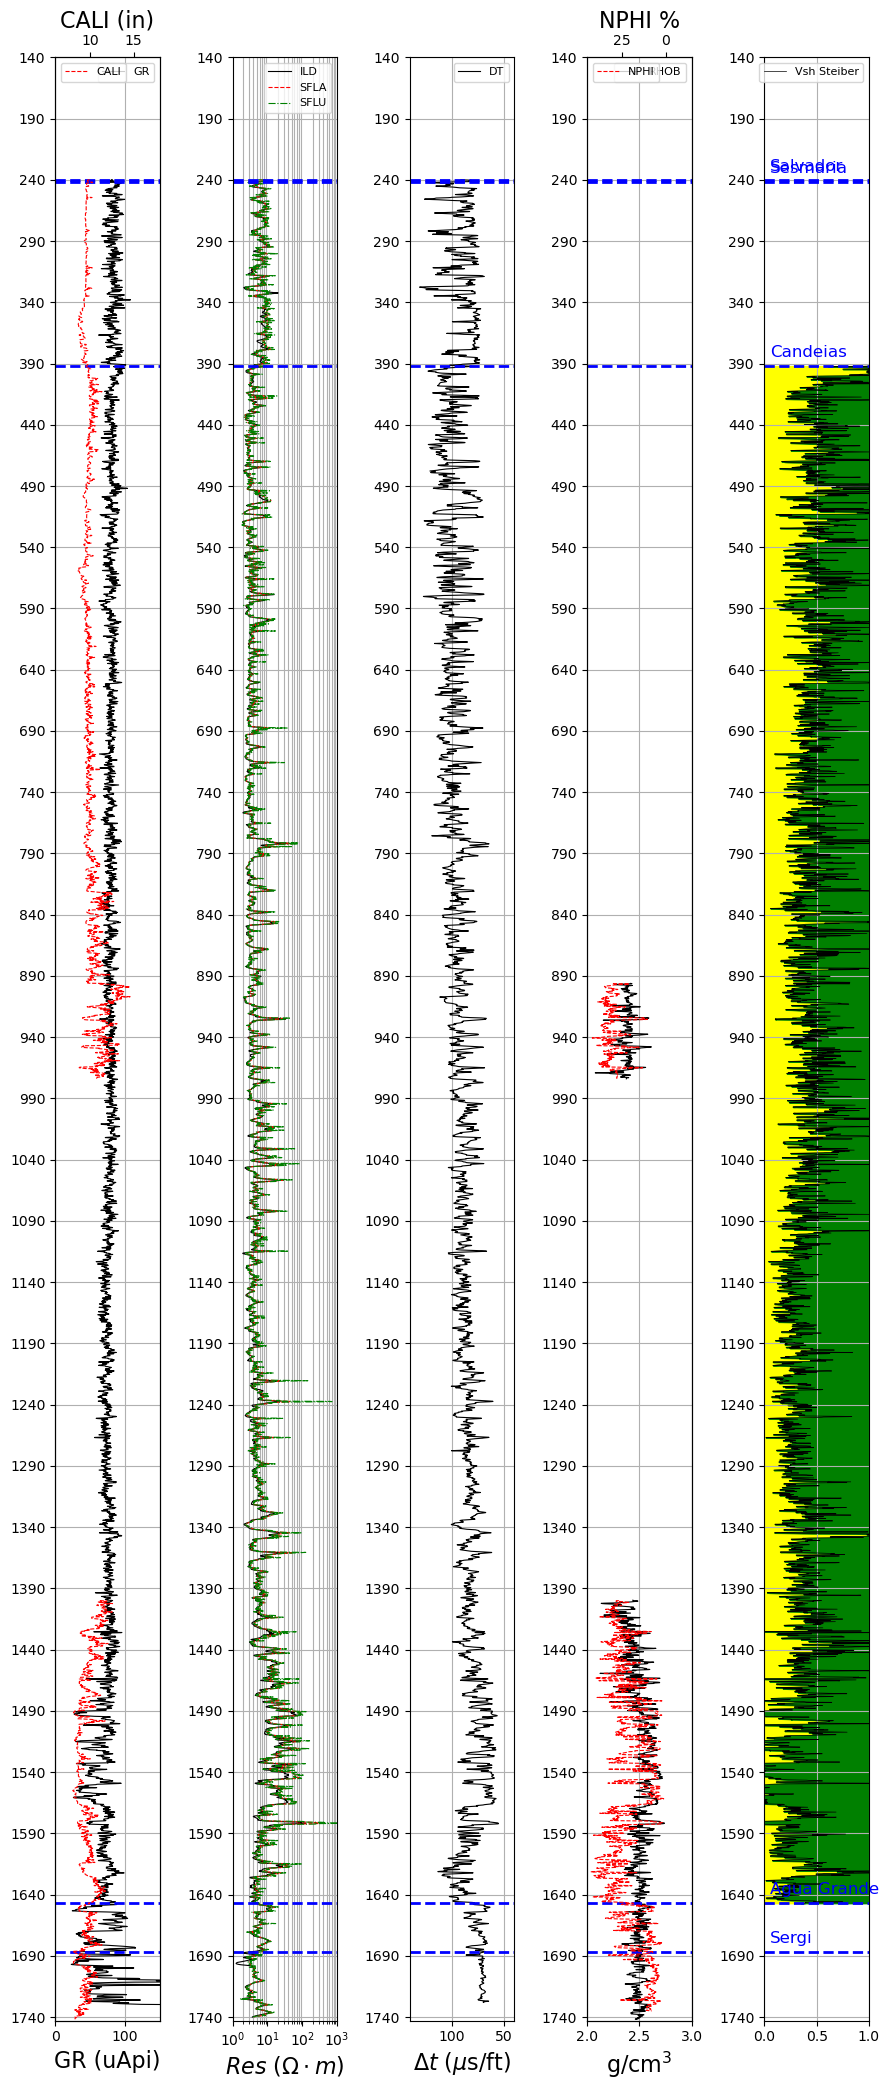

In [21]:
# Plotando as curvas do perfil

fig,axes = plt.subplots(nrows=1, ncols=5, figsize=(9,21))

y_lim = (df.index.min()-100, df.index.max()+1)
step = 50

for ax in axes:
    ax.set_yticks(np.arange(y_lim[0], y_lim[1], step))
    ax.set_ylim(y_lim[0], y_lim[1])
    ax.invert_yaxis()
    ax.grid()
    
axes[0].plot(df.GR,df.index,lw=0.8,color='black',label='GR')
axes[0].set_xlim(0,150)
axes[0].set_xlabel('GR (uApi)',fontsize=16)

#Adicionando um eixo gêmeo para o caliper
axes0 = axes[0].twiny()
axes0.plot(df.CALI,df.index,lw=0.8,color='red',ls='--',label='CALI')
axes0.set_xlabel('CALI (in)',fontsize=16)
axes0.set_xlim(6,18)
axes0.legend(loc='upper left',fontsize=8)
    

axes[1].semilogx(df.ILD,df.index,lw=0.8,color='black',label='ILD')
axes[1].semilogx(df.SFLA,df.index,color='red',lw=0.8,ls='--',label='SFLA')
axes[1].semilogx(df.SFLU,df.index,color='green',lw=0.8,ls='-.',label='SFLU')
axes[1].set_xlabel(r'$Res$ ($\Omega \cdot m$)',fontsize=16)
axes[1].set_xlim(1, 1000)
axes[1].set_xticks([1,10,100,1000])
axes[1].grid(which='both',axis='x')


axes[2].plot(df.DT,df.index,lw=0.8,color='black',label='DT')
axes[2].set_xlim(140,40)
axes[2].set_xlabel(r'$\Delta t$ ($\mu$s/ft)',fontsize=16)


axes[3].plot(df.RHOB,df.index,lw=0.8,color='black',label='RHOB')
axes[3].set_xlim(2,3)
axes[3].set_xlabel(r'g/cm$^3$',fontsize=16)

axes3 = axes[3].twiny()

axes3.plot(df.NPHI,df.index,lw=0.8,color='red',ls='--',label='NPHI')
axes3.set_xlabel('NPHI %',fontsize=16)
axes3.set_xlim(45,-15)
axes3.legend(loc='upper left',fontsize=8)

axes[4].plot(df.Vsh_Steiber,df.index,lw=0.5,color='black',label='Vsh Steiber')
axes[4].fill_betweenx(df.index, 0, df.Vsh_Steiber, color='yellow')
axes[4].fill_betweenx(df.index, df.Vsh_Steiber, 1, color='green')
axes[4].set_xlim(0,1)


# Plotando as formações
for formation in df['Formation'].unique():
    formation_data = df[df['Formation'] == formation]
    formation_min = formation_data.index.min()
    
    for ax in axes:
        ax.legend(fontsize=8)
        ax.axhline(formation_min, color='blue', lw=2, ls='--')
        #Adicionando o nome da Formaçõa imediatamente acima da linha só no último eixo
        if ax == axes[-1]:
            ax.text(ax.get_xlim()[0]+(ax.get_xlim()[1]-ax.get_xlim()[0])*0.05, 
                    formation_min - 5, 
                    formation, 
                    color='blue', 
                    fontsize=12, 
                    verticalalignment='bottom')

fig.tight_layout()